<a href="https://colab.research.google.com/github/KarlaRL666/DataAnalysisPython/blob/main/MetricaClustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================
# Ejemplo básico de clasificación de residuos
# usando aprendizaje no supervisado (K-means + PCA)
# ============================================
# 1. Importar librerías necesarias
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans


In [ ]:
# 2. Simular un dataset de residuos
# Cada fila representa una "imagen" convertida en características numéricas
# (color promedio, textura, forma simplificada)
np.random.seed(42) # Semilla para reproducibilidad

# Generamos datos simulados para 4 tipos de residuos
# Nuevos perfiles de residuos
plastico = np.random.normal([8, 3, 4], 0.8, (100, 3))
papel = np.random.normal([2, 8, 2], 0.8, (100, 3))
vidrio = np.random.normal([7, 7, 9], 0.8, (100, 3))
organico = np.random.normal([4, 2, 8], 0.8, (100, 3))

# Unimos todos los datos en un solo dataset
X = np.vstack([plastico, papel, vidrio, organico])

In [ ]:
# 3. Aplicar K-means para agrupar residuos
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X)

In [ ]:
# 4. Reducir dimensionalidad con PCA para visualizar en 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

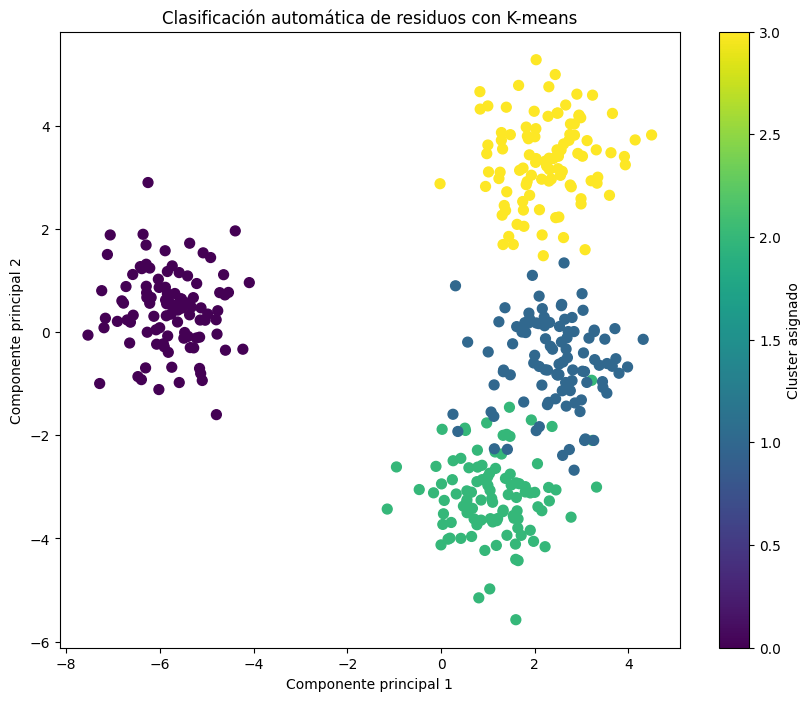

In [ ]:
# 5. Graficar los clusters
plt.figure(figsize=(10,8))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap='viridis', s=50)
plt.title("Clasificación automática de residuos con K-means")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.colorbar(label="Cluster asignado")
plt.show()

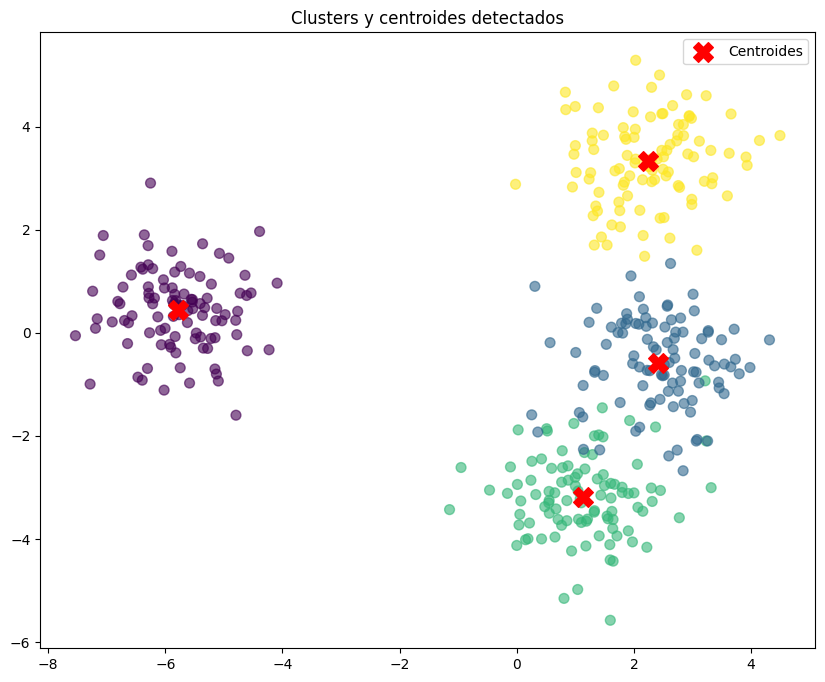

In [ ]:
# 6. Mostrar los centroides en el espacio reducido
centroids_pca = pca.transform(kmeans.cluster_centers_)
plt.figure(figsize=(10,8))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap='viridis', s=50, alpha=0.6)
plt.scatter(centroids_pca[:,0], centroids_pca[:,1], c='red', marker='X', s=200, label='Centroides')
plt.title("Clusters y centroides detectados")
plt.legend()
plt.show()